In [1]:
import ast
import io
from pathlib import Path

import matplotlib as mpl
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

# Academic paper style: clean whitegrid, serif fonts, muted palette.
sns.set_theme(style="whitegrid", context="paper", font_scale=1.15)
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.family": "serif",
    "axes.titleweight": "bold",
    "axes.edgecolor": "0.3",
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.5,
    "legend.frameon": False,
})

FIG_DIR = Path("report/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Text width of a two-column paper (\textwidth for figure*/table*), in inches.
PAGE_W = 7.0
COL_W = 3.35

# Consistent colors: HRM-Text is the accent, baselines are muted greys/blues.
ACCENT = "#c0392b"        # HRM-Text, direct
ACCENT_LIGHT = "#e07b6f"  # HRM-Text, Meta-ICL
MUTED = "#7f8c8d"         # LLM baseline, direct
MUTED_LIGHT = "#b9c0c4"   # LLM baseline, Meta-ICL
TRM_COLOR = "#2c6fbb"     # TRM comparison


def save_fig(fig, name):
    """Export a figure as both vector PDF and raster PNG for the paper."""
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{name}.{ext}")
    return fig


HRM_ARCH = "HRM-Text-1B"

# Short display names keyed by the HuggingFace id found in the run's `model` config.
ARCH_LABELS = {
    "sapientinc/HRM-Text-1B": HRM_ARCH,
    "danish-foundation-models/DFM-Mimir": "DFM-Mimir",
    "google/gemma-4-31B": "Gemma-4-31B",
    "mistralai/Mistral-7B-v0.3": "Mistral-7B",
    "Qwen/Qwen3-4B": "Qwen3-4B",
    "Qwen/Qwen2.5-3B": "Qwen2.5-3B",
    "HuggingFaceTB/SmolLM2-1.7B": "SmolLM2-1.7B",
    "Qwen/Qwen2.5-1.5B": "Qwen2.5-1.5B",
    "meta-llama/Llama-3.2-1B": "Llama-3.2-1B",
    "google/gemma-3-1b-pt": "Gemma-3-1B",
    "Qwen/Qwen3-0.6B": "Qwen3-0.6B",
}

DIRECT, META_ICL = "Standard SFT", "Meta-ICL"

# The 11 GraphQA reasoning tasks (column suffixes in the performance data).
GRAPH_TASKS = [
    "ConnectedNodes", "CycleCheck", "DisconnectedNodes", "EdgeCount",
    "EdgeExistence", "MaximumFlow", "NodeCount", "NodeDegree",
    "Reachability", "ShortestPath", "TriangleCounting",
]

# Compact task headers so an 11-column heatmap/table fits the page width.
TASK_ABBREV = {
    "ConnectedNodes": "ConnNod", "CycleCheck": "Cycle",
    "DisconnectedNodes": "DisconnNod", "EdgeCount": "EdgeCnt",
    "EdgeExistence": "EdgeExist", "MaximumFlow": "MaxFlow",
    "NodeCount": "NodeCnt", "NodeDegree": "NodeDeg",
    "Reachability": "Reach", "ShortestPath": "ShortPath",
    "TriangleCounting": "TriCount",
}


In [2]:
# The ablation W&B export wraps each row in an extra layer of quotes (doubled inner
# quotes), so a plain read_csv collapses everything into one column. Unwrap it first.
def read_wandb_csv(path):
    lines = [ln for ln in Path(path).read_text().splitlines() if ln]
    unwrapped = [
        ln[1:-1].replace('""', '"') if ln.startswith('"') and ln.endswith('"') else ln
        for ln in lines
    ]
    return pd.read_csv(io.StringIO("\n".join(unwrapped)))


ablation_data = read_wandb_csv("data/results/ablation_data.csv")

# The v2 exports are plain CSVs, one file per (model family, evaluation split). Column
# *order* differs between families, so concat aligns on names and NaN-fills the rest.
V2_DIR = Path("data/results/v2")
V2_FAMILIES = ["baseline", "meta-icl", "hrm", "hrm-meta-icl"]
# Late additions, evaluated in-distribution only: no Meta-ICL and no OOD sweep.
V2_ID_ONLY = ["additional_baselines"]


def load_v2(split):
    families = V2_FAMILIES + (V2_ID_ONLY if split == "id" else [])
    return pd.concat(
        [pd.read_csv(V2_DIR / f"{fam}-{split}.csv") for fam in families],
        ignore_index=True,
    )


performance_data = load_v2("id")
# Leave-one-task-out OOD: one run per held-out task, per model.
ood_data = load_v2("ood")

print(f"ID runs: {len(performance_data)}   OOD runs: {len(ood_data)}")


ID runs: 20   OOD runs: 198


# RQ1 — Performance: HRM-Text vs. baselines

Exact-match accuracy on GraphQA over **11 architectures** (20 runs): HRM-Text-1B plus 10
open-weight LLM backbones (Gemma-4-31B, Mistral-7B, Qwen3-4B, Qwen2.5-3B, SmolLM2-1.7B,
Qwen2.5-1.5B, Llama-3.2-1B, Gemma-3-1B, Qwen3-0.6B, DFM-Mimir). Nine of them are trained
under **both** regimes — **directly** and with **Meta-ICL** — while the two late additions
(Gemma-4-31B and DFM-Mimir) were run **direct-only and in-distribution only**; their
Meta-ICL and OOD cells are reported as `--`.

In-distribution (`standard`) results use all 11 tasks. Out-of-distribution generalization is
measured **leave-one-task-out**: each GraphQA task is held out in turn and the model
evaluated on that unseen task; the reported OOD number is the mean over the 11 held-out runs.

> **Caption note:** the ID and OOD panels use *different x-scales*. OOD accuracy is roughly
> an order of magnitude lower than ID, so a shared 0–1 axis would flatten every OOD bar.


In [3]:
# `dataset` and `model` are dict-strings holding the run config. The W&B run `Name`
# is NOT unique (both HRM variants export as "hrm-text-id"), so every key below is
# derived from (architecture, regime) instead.
def enrich(df):
    out = df.copy()
    dataset = out["dataset"].map(ast.literal_eval)
    out["test_type"] = dataset.map(lambda d: d["test_type"])
    out["dataset_config"] = dataset.map(lambda d: d["dataset_config"])
    out["task"] = dataset.map(lambda d: d["ood_task"])
    out["arch"] = out["model"].map(lambda s: ARCH_LABELS[ast.literal_eval(s)["name"]])
    out["regime"] = np.where(out["dataset_config"] == "meta-icl", META_ICL, DIRECT)
    out["model"] = np.where(
        out["regime"] == META_ICL, out["arch"] + f" ({META_ICL})", out["arch"]
    )
    out["exact_match"] = out["val/exact_match"].astype(float)
    return out


perf_id = (
    enrich(performance_data)
    .sort_values("Created")
    .drop_duplicates(subset=["arch", "regime"], keep="last")
    .reset_index(drop=True)
)

# For OOD runs only the held-out task's column is populated, so `val/exact_match`
# already is that task's score.
ood = (
    enrich(ood_data)
    .sort_values("Created")
    .drop_duplicates(subset=["arch", "regime", "task"], keep="last")
    .reset_index(drop=True)
)

# One shared ordering: architectures ranked by direct-regime ID accuracy, HRM-Text
# pinned first; rows are then grouped into a Direct block and a Meta-ICL block.
_direct_rank = (
    perf_id[perf_id["regime"] == DIRECT]
    .set_index("arch")["exact_match"]
    .sort_values(ascending=False)
)
ARCH_ORDER = [HRM_ARCH] + [a for a in _direct_rank.index if a != HRM_ARCH]
# The ID-only additions have no Meta-ICL counterpart, so the two blocks differ in size.
_have_meta = set(perf_id.loc[perf_id["regime"] == META_ICL, "arch"])
META_ORDER = [f"{a} ({META_ICL})" for a in ARCH_ORDER if a in _have_meta]
MODEL_ORDER = ARCH_ORDER + META_ORDER
N_DIRECT = len(ARCH_ORDER)

perf_id["model"] = pd.Categorical(perf_id["model"], MODEL_ORDER, ordered=True)
perf_id = perf_id.sort_values("model").reset_index(drop=True)
perf_id["model"] = perf_id["model"].astype(str)

# Models x held-out-task matrix (canonical task order) + mean OOD per model.
ood_by_task = (
    ood.pivot(index="model", columns="task", values="exact_match")
    .reindex(index=MODEL_ORDER, columns=GRAPH_TASKS)
)
# Models x task matrix for the in-distribution runs.
id_by_task = perf_id.set_index("model")[[f"val/exact_match_{t}" for t in GRAPH_TASKS]]
id_by_task.columns = GRAPH_TASKS
id_by_task = id_by_task.reindex(MODEL_ORDER)

overall_id = perf_id.set_index("model")["exact_match"].reindex(MODEL_ORDER)
overall_ood = ood_by_task.mean(axis=1)

# Models evaluated OOD must be complete; the ID-only additions are allowed to be absent.
OOD_MODELS = [m for m in MODEL_ORDER if m in set(ood["model"])]
assert len(perf_id) == len(MODEL_ORDER) == 20, "unexpected v2 coverage"
assert id_by_task.notna().all().all(), "missing in-distribution per-task scores"
assert ood_by_task.loc[OOD_MODELS].notna().all().all(), "incomplete OOD sweep"
pd.DataFrame({"ID": overall_id, "OOD (mean)": overall_ood}).round(3)


,ID,OOD (mean)
model,,
HRM-Text-1B,0.831,0.407
DFM-Mimir,0.847,NaN
Gemma-4-31B,0.813,NaN
Qwen3-0.6B,0.725,0.133
Qwen3-4B,0.722,0.279
Qwen2.5-3B,0.717,0.120
Qwen2.5-1.5B,0.701,0.092
SmolLM2-1.7B,0.686,0.141
Gemma-3-1B,0.655,0.065


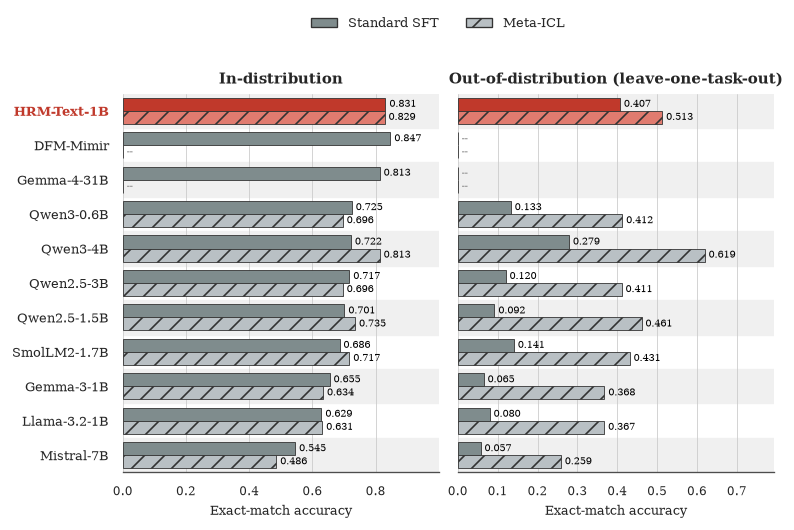

In [4]:
# Main RQ1 figure (full-width `figure*`): one row per architecture, paired bars for the
# Direct and Meta-ICL regimes. ID and OOD sit in separate panels because OOD accuracy is
# an order of magnitude smaller and would be invisible on a shared 0-1 axis.
def plot_id_ood_panels(fname="perf_overall_id_ood"):
    y = np.arange(len(ARCH_ORDER))
    h = 0.38
    fig, axes = plt.subplots(
        1, 2, figsize=(PAGE_W, 4.1), sharey=True, gridspec_kw={"wspace": 0.06}
    )

    panels = [
        (axes[0], overall_id, "In-distribution", (0, 1.0)),
        (axes[1], overall_ood, "Out-of-distribution (leave-one-task-out)", None),
    ]
    for ax, series, title, xlim in panels:
        for i in range(0, len(ARCH_ORDER), 2):
            ax.axhspan(i - 0.5, i + 0.5, color="0.94", zorder=0)

        direct = np.array([series.get(a, np.nan) for a in ARCH_ORDER], dtype=float)
        meta = np.array(
            [series.get(f"{a} ({META_ICL})", np.nan) for a in ARCH_ORDER], dtype=float
        )
        is_hrm = [a == HRM_ARCH for a in ARCH_ORDER]

        groups = [
            (y - h / 2, direct, [ACCENT if k else MUTED for k in is_hrm], None),
            (y + h / 2, meta, [ACCENT_LIGHT if k else MUTED_LIGHT for k in is_hrm], "//"),
        ]
        top = np.nanmax(np.concatenate([direct, meta]))
        hi = xlim[1] if xlim else top * 1.28
        for ypos, vals, colors, hatch in groups:
            bars = ax.barh(ypos, np.nan_to_num(vals), height=h, color=colors,
                           edgecolor="0.2", linewidth=0.5, hatch=hatch, zorder=2)
            for bar, v in zip(bars, vals):
                # Runs that were never evaluated in this cell get a dash, not a 0.000.
                label = "--" if np.isnan(v) else f"{v:.3f}"
                ax.text(np.nan_to_num(v) + hi * 0.012,
                        bar.get_y() + bar.get_height() / 2,
                        label, va="center", ha="left", fontsize=6,
                        color="0.55" if np.isnan(v) else "black", zorder=3)

        ax.set_xlim(0, hi)
        ax.set_title(title, fontsize=9)
        ax.set_xlabel("Exact-match accuracy", fontsize=8)
        ax.tick_params(axis="x", labelsize=7)
        ax.grid(axis="y", visible=False)
        ax.set_axisbelow(True)

    # Drop the left panel's final tick so it does not collide with the right panel's 0.0.
    axes[0].set_xticks(np.arange(0, 1.0, 0.2))
    axes[0].set_yticks(y)
    axes[0].set_yticklabels(ARCH_ORDER, fontsize=8)
    axes[0].set_ylim(len(ARCH_ORDER) - 0.5, -0.5)  # best architecture on top
    for lbl, hrm in zip(axes[0].get_yticklabels(), [a == HRM_ARCH for a in ARCH_ORDER]):
        if hrm:
            lbl.set_color(ACCENT)
            lbl.set_fontweight("bold")

    handles = [
        mpl.patches.Patch(facecolor=MUTED, edgecolor="0.2", label=DIRECT),
        mpl.patches.Patch(facecolor=MUTED_LIGHT, edgecolor="0.2", hatch="//", label=META_ICL),
    ]
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.06),
               ncol=2, fontsize=8, frameon=False)
    sns.despine(fig=fig, left=True)
    save_fig(fig, fname)
    plt.show()


plot_id_ood_panels()


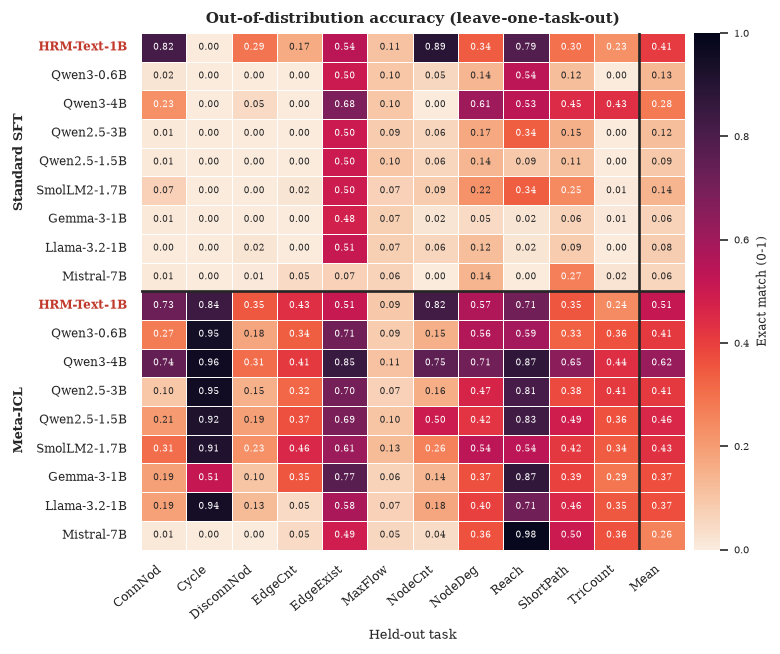

In [5]:
# Full-width per-task heatmap: rows are (architecture x regime) split into a Direct block
# and a Meta-ICL block, so a row label only needs the architecture name.
def plot_task_heatmap(mat, title, fname, vmax, xlabel=""):
    mat = mat.dropna(how="all")  # ID-only additions have no OOD sweep
    block = sum(META_ICL not in str(m) for m in mat.index)
    annotated = mat.copy()
    annotated["Mean"] = mat.mean(axis=1)

    fig, ax = plt.subplots(figsize=(PAGE_W, 0.255 * len(mat) + 1.0))
    sns.heatmap(
        annotated, annot=True, fmt=".2f", cmap="rocket_r", vmin=0, vmax=vmax,
        linewidths=0.4, linecolor="white", annot_kws={"fontsize": 5.5},
        cbar_kws={"label": f"Exact match (0-{vmax:g})", "pad": 0.015}, ax=ax,
    )
    ax.axhline(block, color="0.15", linewidth=1.6)          # regime separator
    ax.axvline(len(GRAPH_TASKS), color="0.15", linewidth=1.6)  # Mean separator

    ax.set_xticklabels([TASK_ABBREV.get(c, c) for c in annotated.columns],
                       rotation=40, ha="right", fontsize=7)
    ax.set_yticklabels([str(m).replace(f" ({META_ICL})", "") for m in mat.index],
                       rotation=0, fontsize=7)
    for lbl in ax.get_yticklabels():
        if lbl.get_text() == HRM_ARCH:
            lbl.set_color(ACCENT)
            lbl.set_fontweight("bold")

    # Label each regime block once, clear of the architecture tick labels.
    for name, lo, hi in [(DIRECT, 0, block), (META_ICL, block, len(mat))]:
        ax.text(-0.225, (lo + hi) / 2, name, transform=ax.get_yaxis_transform(),
                rotation=90, va="center", ha="center", fontsize=8, fontweight="bold")

    ax.set_ylabel("")
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.figure.axes[-1].yaxis.label.set_size(7)
    ax.figure.axes[-1].tick_params(labelsize=6)
    save_fig(fig, fname)
    plt.show()


# OOD accuracy is far below 1.0 on most cells, so derive the color cap from the data.
ood_vmax = np.ceil(np.nanmax(ood_by_task.to_numpy()) * 10) / 10
plot_task_heatmap(
    ood_by_task,
    "Out-of-distribution accuracy (leave-one-task-out)",
    "perf_ood_by_task",
    vmax=ood_vmax,
    xlabel="Held-out task",
)


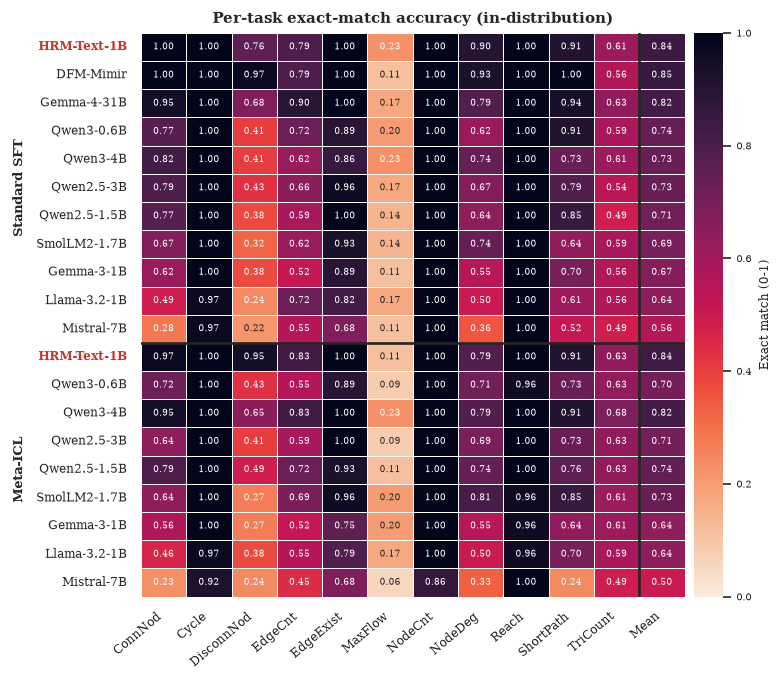

In [6]:
plot_task_heatmap(
    id_by_task,
    "Per-task exact-match accuracy (in-distribution)",
    "perf_by_task",
    vmax=1.0,
)


In [7]:
# Single full-width `table*`: models as rows (Direct / Meta-ICL blocks), the 11 tasks plus
# a Mean as column groups, each split into an ID and an OOD sub-column.
def combined_task_table_latex(id_mat, ood_mat, caption, label):
    def with_mean(mat):
        out = mat.copy()
        out["Mean"] = mat.mean(axis=1)
        return out

    idm, oodm = with_mean(id_mat), with_mean(ood_mat)
    groups = [TASK_ABBREV.get(c, c) for c in idm.columns]
    tbl = pd.concat(
        {g: pd.DataFrame({"ID": idm[c], "OOD": oodm[c]})
         for g, c in zip(groups, idm.columns)},
        axis=1,
    ).reindex(columns=pd.MultiIndex.from_product([groups, ["ID", "OOD"]]))
    tbl.index = [str(m).replace(f" ({META_ICL})", "") for m in id_mat.index]

    # Drop the leading zero (".84") so 24 numeric columns still fit the text width.
    def fmt(v):
        if pd.isna(v):
            return "--"
        return f"{v:.2f}".lstrip("0") if v < 1 else f"{v:.2f}"

    lines = tbl.to_latex(
        float_format=fmt,
        column_format="l|" + "cc|" * (len(groups) - 1) + "cc",
        escape=False, na_rep="--", multicolumn=True, multicolumn_format="c",
    ).splitlines()

    ncol = 1 + 2 * len(groups)
    # The two regime blocks differ in size: some architectures are direct-only.
    n_direct = sum(META_ICL not in str(m) for m in id_mat.index)
    n_rows = len(tbl)
    head = lines.index(r"\midrule")
    rows = lines[head + 1: head + 1 + n_rows]
    for i in (0, n_direct):  # HRM-Text is pinned first in each block
        rows[i] = rows[i].replace(HRM_ARCH, rf"\textbf{{{HRM_ARCH}}}", 1)

    cmid = " ".join(
        rf"\cmidrule(lr){{{2 + 2 * j}-{3 + 2 * j}}}" for j in range(len(groups))
    )

    def banner(name):
        return rf"\multicolumn{{{ncol}}}{{l}}{{\textit{{{name}}}}} \\"

    top = lines.index(r"\toprule")
    body = (
        lines[: top + 2] + [cmid] + lines[top + 2: head + 1]
        + [banner(DIRECT)] + rows[:n_direct]
        + [r"\midrule", banner(META_ICL)] + rows[n_direct:]
        + lines[head + 1 + n_rows:]
    )
    return "\n".join([
        r"\begin{table*}[t]", r"\centering", r"\small",
        rf"\caption{{{caption}}}", rf"\label{{{label}}}",
        r"\resizebox{\textwidth}{!}{%",
        *body,
        r"}",
        r"\end{table*}",
    ])


print(combined_task_table_latex(
    id_by_task,
    ood_by_task,
    "GraphQA exact-match accuracy per task. \\textbf{ID}: in-distribution. "
    "\\textbf{OOD}: leave-one-task-out, i.e.\\ the task was held out of training. "
    "Gemma-4-31B and DFM-Mimir were run in-distribution only, so their OOD cells are "
    "\\texttt{--}. Leading zeros omitted.",
    "tab:perf_by_task",
))


\begin{table*}[t]
\centering
\small
\caption{GraphQA exact-match accuracy per task. \textbf{ID}: in-distribution. \textbf{OOD}: leave-one-task-out, i.e.\ the task was held out of training. Gemma-4-31B and DFM-Mimir were run in-distribution only, so their OOD cells are \texttt{--}. Leading zeros omitted.}
\label{tab:perf_by_task}
\resizebox{\textwidth}{!}{%
\begin{tabular}{l|cc|cc|cc|cc|cc|cc|cc|cc|cc|cc|cc|cc}
\toprule
 & \multicolumn{2}{c}{ConnNod} & \multicolumn{2}{c}{Cycle} & \multicolumn{2}{c}{DisconnNod} & \multicolumn{2}{c}{EdgeCnt} & \multicolumn{2}{c}{EdgeExist} & \multicolumn{2}{c}{MaxFlow} & \multicolumn{2}{c}{NodeCnt} & \multicolumn{2}{c}{NodeDeg} & \multicolumn{2}{c}{Reach} & \multicolumn{2}{c}{ShortPath} & \multicolumn{2}{c}{TriCount} & \multicolumn{2}{c}{Mean} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5} \cmidrule(lr){6-7} \cmidrule(lr){8-9} \cmidrule(lr){10-11} \cmidrule(lr){12-13} \cmidrule(lr){14-15} \cmidrule(lr){16-17} \cmidrule(lr){18-19} \cmidrule(lr){20-21} \cmidrule(

In [8]:
# Compact single-column headline table: 11 architectures x {ID, OOD} x {Direct, Meta-ICL}.
# The old per-task ID/OOD cross-table would have needed 44 numeric columns.
summary = pd.DataFrame(
    {
        ("ID", DIRECT): overall_id.reindex(ARCH_ORDER).to_numpy(),
        ("ID", META_ICL): overall_id.reindex(
            [f"{a} ({META_ICL})" for a in ARCH_ORDER]).to_numpy(),
        ("OOD", DIRECT): overall_ood.reindex(ARCH_ORDER).to_numpy(),
        ("OOD", META_ICL): overall_ood.reindex(
            [f"{a} ({META_ICL})" for a in ARCH_ORDER]).to_numpy(),
    },
    index=ARCH_ORDER,
)
summary.columns = pd.MultiIndex.from_tuples(summary.columns)

summary_lines = summary.round(3).to_latex(
    float_format="{:.3f}".format,
    column_format="l|cc|cc",
    escape=False,
    na_rep="--",
    multicolumn=True,
    multicolumn_format="c",
).splitlines()
head = summary_lines.index(r"\midrule")
summary_lines[head + 1] = summary_lines[head + 1].replace(
    HRM_ARCH, rf"\textbf{{{HRM_ARCH}}}", 1
)

print("\n".join([
    r"\begin{table}[t]", r"\centering", r"\small",
    r"\caption{GraphQA exact-match accuracy. OOD is the mean over the 11 "
    r"leave-one-task-out evaluations. Gemma-4-31B and DFM-Mimir were run under the "
    r"standard-SFT regime in-distribution only; \texttt{--} marks an evaluation that "
    r"was not performed.}",
    r"\label{tab:perf_summary}",
    *summary_lines,
    r"\end{table}",
]))

summary.round(3)


\begin{table}[t]
\centering
\small
\caption{GraphQA exact-match accuracy. OOD is the mean over the 11 leave-one-task-out evaluations. Gemma-4-31B and DFM-Mimir were run under the standard-SFT regime in-distribution only; \texttt{--} marks an evaluation that was not performed.}
\label{tab:perf_summary}
\begin{tabular}{l|cc|cc}
\toprule
 & \multicolumn{2}{c}{ID} & \multicolumn{2}{c}{OOD} \\
 & Standard SFT & Meta-ICL & Standard SFT & Meta-ICL \\
\midrule
\textbf{HRM-Text-1B} & 0.831 & 0.829 & 0.407 & 0.513 \\
DFM-Mimir & 0.847 & -- & -- & -- \\
Gemma-4-31B & 0.813 & -- & -- & -- \\
Qwen3-0.6B & 0.725 & 0.696 & 0.133 & 0.412 \\
Qwen3-4B & 0.722 & 0.813 & 0.279 & 0.619 \\
Qwen2.5-3B & 0.717 & 0.696 & 0.120 & 0.411 \\
Qwen2.5-1.5B & 0.701 & 0.735 & 0.092 & 0.461 \\
SmolLM2-1.7B & 0.686 & 0.717 & 0.141 & 0.431 \\
Gemma-3-1B & 0.655 & 0.634 & 0.065 & 0.368 \\
Llama-3.2-1B & 0.629 & 0.631 & 0.080 & 0.367 \\
Mistral-7B & 0.545 & 0.486 & 0.057 & 0.259 \\
\bottomrule
\end{tabular}
\end{table}


ID                   OOD         
             Standard SFT Meta-ICL Standard SFT Meta-ICL
HRM-Text-1B         0.831    0.829        0.407    0.513
DFM-Mimir           0.847      NaN          NaN      NaN
Gemma-4-31B         0.813      NaN          NaN      NaN
Qwen3-0.6B          0.725    0.696        0.133    0.412
Qwen3-4B            0.722    0.813        0.279    0.619
Qwen2.5-3B          0.717    0.696        0.120    0.411
Qwen2.5-1.5B        0.701    0.735        0.092    0.461
SmolLM2-1.7B        0.686    0.717        0.141    0.431
Gemma-3-1B          0.655    0.634        0.065    0.368
Llama-3.2-1B        0.629    0.631        0.080    0.367
Mistral-7B          0.545    0.486        0.057    0.259

# RQ2 — Ablation: the L/H ratio drives performance

Two effects on GraphQA test accuracy, shown for both HRM and TRM:

1. **The L/H ratio is decisive (axis 2).** Raising the low-level-to-high-level cycle
   ratio $L/H$ improves accuracy, peaking at the largest ratio. For HRM, ratios below 1
   collapse performance entirely, whereas TRM is markedly more robust to the ratio.
2. **Pure recursion at a fixed ratio hurts.** Holding $L/H = 1.5$ fixed and simply scaling
   up the number of recurrent cycles degrades accuracy to zero — for both HRM and TRM.


In [15]:
# Clean ablation runs: drop those without an eval score, recompute the true L/H ratio.
abl = ablation_data.copy()
abl = abl[abl["eval/accuracy"].notna()].copy()
abl["accuracy"] = abl["eval/accuracy"].astype(float)
abl["H"] = abl["H_cycles"].astype(int)
abl["L"] = abl["L_cycles"].astype(int)
abl["ratio"] = abl["L"] / abl["H"]
abl["family"] = np.where(abl["Name"].str.contains("trm"), "TRM", "HRM")

# Average any repeated (family, H, L) runs.
abl = (
    abl.groupby(["family", "H", "L", "ratio"], as_index=False)["accuracy"]
    .mean()
    .sort_values(["family", "ratio"])
)
abl


,family,H,L,ratio,accuracy
6,HRM,6,2,0.333333,0.000000
4,HRM,4,3,0.750000,0.062338
3,HRM,3,4,1.333333,0.400000
1,HRM,2,3,1.500000,0.444156
5,HRM,4,6,1.500000,0.054545
7,HRM,6,9,1.500000,0.000000
8,HRM,8,12,1.500000,0.000000
2,HRM,2,6,3.000000,0.438961
0,HRM,1,12,12.000000,0.514286
15,TRM,6,2,0.333333,0.376623


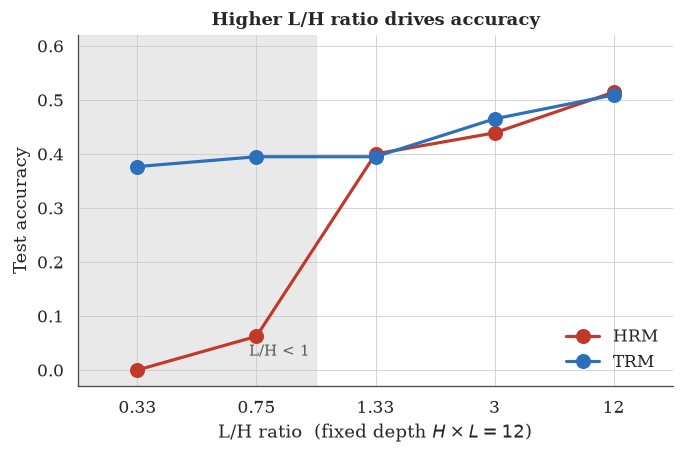

In [16]:
# Axis 2 — ratio effect for HRM and TRM. Hold the total recurrence depth H*L = 12 fixed
# and vary only the L/H ratio. Evenly-spaced x keeps close ratios legible.
def ratio_sweep(family):
    sub = abl[(abl["family"] == family) & (abl["H"] * abl["L"] == 12)]
    return sub.sort_values("ratio").reset_index(drop=True)


hrm_curve = ratio_sweep("HRM")
trm_curve = ratio_sweep("TRM")

# Shared, ordered ratio axis across both families.
ratios = sorted(set(hrm_curve["ratio"]) | set(trm_curve["ratio"]))
pos = {r: i for i, r in enumerate(ratios)}

fig, ax = plt.subplots(figsize=(6.4, 3.8))
n_below = sum(r < 1 for r in ratios)
ax.axvspan(-0.5, n_below - 0.5, color="0.88", alpha=0.7, zorder=0)
ax.text(n_below - 0.55, 0.02, "L/H < 1", fontsize=9, color="0.35", ha="right", va="bottom")

for curve, color, label in [(hrm_curve, ACCENT, "HRM"), (trm_curve, TRM_COLOR, "TRM")]:
    xs = [pos[r] for r in curve["ratio"]]
    ax.plot(xs, curve["accuracy"], marker="o", color=color, markersize=8,
            linewidth=1.9, label=label, zorder=3)

ax.set_xticks(range(len(ratios)))
ax.set_xticklabels([f"{r:.2f}".rstrip("0").rstrip(".") for r in ratios])
ax.set_xlim(-0.5, len(ratios) - 0.5)
ax.set_xlabel("L/H ratio  (fixed depth $H \\times L = 12$)")
ax.set_ylabel("Test accuracy")
ax.set_ylim(-0.03, 0.62)
ax.set_title("Higher L/H ratio drives accuracy")
ax.legend(title="")
sns.despine(ax=ax)
save_fig(fig, "ablation_ratio")
plt.show()


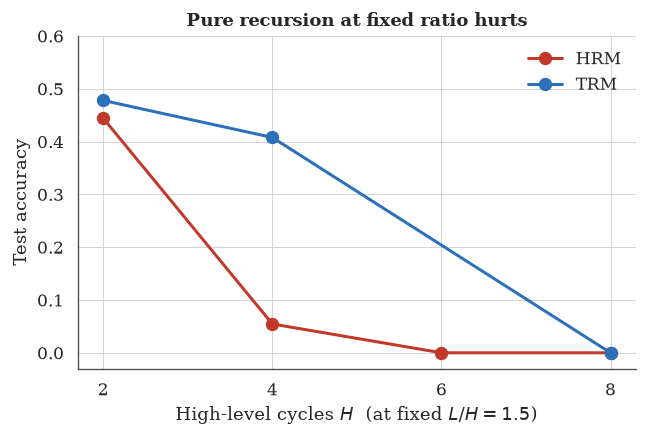

In [17]:
# Fixed-ratio scaling. Hold L/H = 1.5 and increase recurrence depth (H) for HRM and TRM.
fixed = abl[np.isclose(abl["ratio"], 1.5)].sort_values(["family", "H"])

fig, ax = plt.subplots(figsize=(6.0, 3.6))
for fam, color in [("HRM", ACCENT), ("TRM", TRM_COLOR)]:
    sub = fixed[fixed["family"] == fam]
    ax.plot(sub["H"], sub["accuracy"], marker="o", markersize=7, linewidth=1.8,
            color=color, label=fam)

ax.set_xlabel("High-level cycles $H$  (at fixed $L/H = 1.5$)")
ax.set_ylabel("Test accuracy")
ax.set_ylim(-0.03, 0.6)
ax.set_xticks(sorted(fixed["H"].unique()))
ax.set_title("Pure recursion at fixed ratio hurts")
ax.legend(title="")
sns.despine(ax=ax)
save_fig(fig, "ablation_fixed_ratio")
plt.show()


# RQ2b — The full $(H, L)$ grid

The two sweeps above each hold one quantity fixed ($H \times L = 12$, or $L/H = 1.5$),
which makes the ratio and the total recurrence depth inseparable: at fixed depth $D$ the
ratio is forced to $L/H = D/H^2$, and at fixed ratio $r$ the depth is forced to
$H \times L = r H^2$. A single degree of freedom therefore drives both curves.

The heatmap below drops that constraint and reports accuracy for every measured
$(H, L)$ cell, so the high-level and low-level cycle counts can be read as independent
factors. Iso-ratio lines run diagonally (outlined cells are $L/H = 1$); iso-depth lines
are hyperbolas. Grey cells were not run.


In [18]:
# Shared axes across both families so the two panels are cell-for-cell comparable.
H_VALS = sorted(abl["H"].unique())
L_VALS = sorted(abl["L"].unique())


def hl_grid(family, values="accuracy"):
    return (
        abl[abl["family"] == family]
        .pivot_table(index="H", columns="L", values=values, aggfunc="mean")
        .reindex(index=H_VALS, columns=L_VALS)
    )


hrm_grid, trm_grid = hl_grid("HRM"), hl_grid("TRM")
pd.concat({"HRM": hrm_grid, "TRM": trm_grid}, names=["family"]).round(3)


L            2      3      4      6    9      12
family H                                        
HRM    1    NaN    NaN    NaN    NaN  NaN  0.514
       2    NaN  0.444    NaN  0.439  NaN    NaN
       3    NaN    NaN  0.400    NaN  NaN    NaN
       4    NaN  0.062    NaN  0.055  NaN    NaN
       6  0.000    NaN    NaN    NaN  0.0    NaN
       8    NaN    NaN    NaN    NaN  NaN  0.000
TRM    1    NaN    NaN    NaN    NaN  NaN  0.509
       2    NaN  0.478    NaN  0.465  NaN    NaN
       3    NaN    NaN  0.395    NaN  NaN    NaN
       4    NaN  0.395    NaN  0.408  NaN    NaN
       6  0.377    NaN    NaN    NaN  NaN    NaN
       8    NaN    NaN    NaN    NaN  NaN  0.000

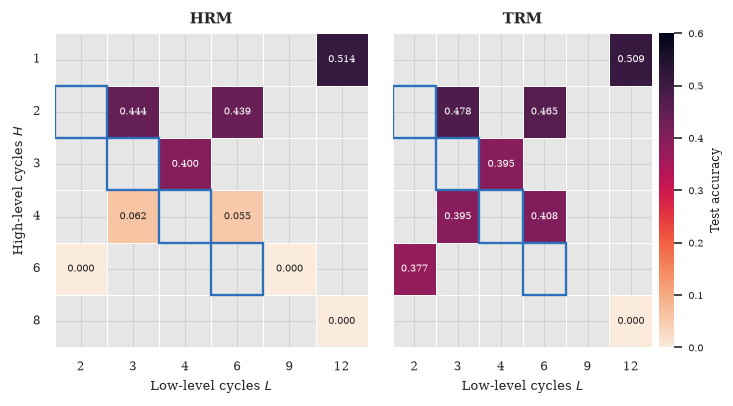

In [ ]:
# Full-width `figure*`: accuracy over the (H, L) grid, one panel per family.
# No `sharey`: seaborn rewrites the tick labels per axes, which a shared y-axis drops.
def plot_hl_heatmaps(fname="ablation_hl_grid"):
    vmax = np.ceil(abl["accuracy"].max() * 10) / 10
    fig, axes = plt.subplots(1, 2, figsize=(PAGE_W, 3.4), gridspec_kw={"wspace": 0.08})

    for ax, (fam, grid) in zip(axes, [("HRM", hrm_grid), ("TRM", trm_grid)]):
        last = fam == "TRM"
        sns.heatmap(
            grid, ax=ax, mask=grid.isna(), annot=True, fmt=".3f", cmap="rocket_r",
            vmin=0, vmax=vmax, linewidths=0.4, linecolor="white",
            annot_kws={"fontsize": 6}, cbar=last,
            cbar_kws={"label": "Test accuracy", "pad": 0.02} if last else None,
        )
        ax.set_facecolor("0.90")  # cells with no run

        # Outline the L/H = 1 diagonal: cells above it are high-level dominated.
        for i, h in enumerate(H_VALS):
            if h in L_VALS:
                ax.add_patch(mpl.patches.Rectangle(
                    (L_VALS.index(h), i), 1, 1, fill=False,
                    edgecolor=TRM_COLOR, linewidth=1.4, zorder=4,
                ))

        ax.set_title(fam, fontsize=9)
        ax.set_xlabel("Low-level cycles $L$", fontsize=8)
        ax.set_xticklabels(L_VALS, rotation=0, fontsize=7)
        ax.set_yticklabels(H_VALS if not last else [], rotation=0, fontsize=7)
        ax.set_ylabel("High-level cycles $H$" if not last else "", fontsize=8)

    cbar_ax = fig.axes[-1]
    cbar_ax.yaxis.label.set_size(7)
    cbar_ax.tick_params(labelsize=6)
    save_fig(fig, fname)
    plt.show()


plot_hl_heatmaps()

# RQ3 — Real knowledge-graph QA: MetaQA and KQA-Pro

GraphQA is synthetic. RQ3 asks whether the same picture holds on two established KGQA
benchmarks, where the model must read a linearized set of `(s, p, o)` triples and answer a
natural-language question.

**MetaQA** is evaluated under four context conditions. *Gold-$k$* supplies a gold subgraph of
~80 triples and keeps only questions whose gold answer set has exactly $k$ elements
($k \in \{1, 5, 10\}$), so it sweeps **answer-set cardinality** at fixed context size.
*Retrieved-1* keeps single-answer questions but replaces the gold subgraph with a
**retrieved** one, so it is the realistic counterpart of Gold-1. Because answers are sets, we
report both answer-set **F1** (partial credit) and **exact match** (the full set must be
right); the gap between them is what answer cardinality costs.

**KQA-Pro** is a single split annotated with seven **question types** (Basic, Comparison,
Count, Logical, Multihop, Qualifier, Verify), which isolates *which kind* of reasoning each
model can do. Every panel carries the random-answer control, since Verify is binary and
Count has a small label set — both are far from 0 by chance.

All RQ3 runs use the standard-SFT regime; no Meta-ICL or OOD sweep was run on these
benchmarks.


In [9]:
# Both KGQA benchmarks are plain W&B exports with one row per (model, context variant).
RESULTS_DIR = Path("data/results")

METAQA_VARIANTS = {
    "metaqa-gold-1": "Gold-1",
    "metaqa-gold-5": "Gold-5",
    "metaqa-gold-10": "Gold-10",
    "metaqa-retrieved-1": "Retrieved-1",
}
VARIANT_ORDER = list(METAQA_VARIANTS.values())
HOPS = ["1hop", "2hop", "3hop"]
KQA_TYPES = [
    "Basic", "Comparison", "Count", "Logical", "Multihop", "Qualifier", "Verify",
]
RANDOM_LABEL = "Random answer"


def load_kgqa(name):
    df = pd.read_csv(RESULTS_DIR / f"{name}.csv")
    cfg = df["dataset"].map(ast.literal_eval)
    df["arch"] = df["model"].map(lambda s: ARCH_LABELS[ast.literal_eval(s)["name"]])
    df["variant"] = cfg.map(lambda d: METAQA_VARIANTS.get(d["name"], d["name"]))
    return (
        df.sort_values("Created")
        .drop_duplicates(subset=["arch", "variant"], keep="last")
        .reset_index(drop=True)
    )


def rank_archs(scores):
    """HRM-Text pinned first, every other architecture ranked by `scores`."""
    rest = scores.drop(index=HRM_ARCH, errors="ignore").sort_values(ascending=False)
    return [HRM_ARCH] + list(rest.index)


metaqa = load_kgqa("metaqa-variants")
kqapro = load_kgqa("kqa-pro").set_index("arch")


def metaqa_matrix(metric):
    return metaqa.pivot(index="arch", columns="variant", values=metric)[VARIANT_ORDER]


metaqa_f1 = metaqa_matrix("val/set_f1")
METAQA_ORDER = rank_archs(metaqa_f1.mean(axis=1))
metaqa_f1 = metaqa_f1.reindex(METAQA_ORDER)
metaqa_em = metaqa_matrix("val/exact_match").reindex(METAQA_ORDER)
# Strongest non-HRM architecture, highlighted in every RQ3 panel.
METAQA_BEST = metaqa_f1.drop(index=HRM_ARCH).mean(axis=1).idxmax()

# The random-answer control depends only on the variant, so one value per variant.
metaqa_random = (
    metaqa.groupby("variant")[[f"val/random_baseline_{h}" for h in HOPS]]
    .mean().mean(axis=1)[VARIANT_ORDER]
)

KQA_ORDER = rank_archs(kqapro["val/exact_match"])
kqa_by_type = kqapro[[f"val/exact_match_{t}" for t in KQA_TYPES]].reindex(KQA_ORDER)
kqa_by_type.columns = KQA_TYPES
kqa_random = kqapro[[f"val/random_baseline_{t}" for t in KQA_TYPES]]
assert (kqa_random.nunique() == 1).all(), "random control should not vary by model"
kqa_random = kqa_random.iloc[0].set_axis(KQA_TYPES)

assert len(metaqa) == len(METAQA_ORDER) * len(VARIANT_ORDER)
assert metaqa_f1.notna().all().all() and kqa_by_type.notna().all().all()
print(f"MetaQA: {len(METAQA_ORDER)} models x {len(VARIANT_ORDER)} variants   "
      f"KQA-Pro: {len(KQA_ORDER)} models   best MetaQA baseline: {METAQA_BEST}")
metaqa_f1.round(3)


MetaQA: 9 models x 4 variants   KQA-Pro: 8 models   best MetaQA baseline: Qwen3-4B


/tmp/ipykernel_283803/1604385216.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["arch"] = df["model"].map(lambda s: ARCH_LABELS[ast.literal_eval(s)["name"]])
/tmp/ipykernel_283803/1604385216.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["variant"] = cfg.map(lambda d: METAQA_VARIANTS.get(d["name"], d["name"]))
/tmp/ipykernel_283803/1604385216.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining 

variant,Gold-1,Gold-5,Gold-10,Retrieved-1
arch,,,,
HRM-Text-1B,0.982,0.882,0.892,0.726
Qwen3-4B,0.987,0.938,0.922,0.766
Qwen2.5-3B,0.977,0.906,0.886,0.695
Qwen2.5-1.5B,0.950,0.895,0.863,0.711
Llama-3.2-1B,0.935,0.868,0.873,0.688
Qwen3-0.6B,0.942,0.887,0.841,0.688
Gemma-3-1B,0.897,0.842,0.847,0.650
SmolLM2-1.7B,0.905,0.796,0.768,0.693
Mistral-7B,0.659,0.763,0.787,0.475


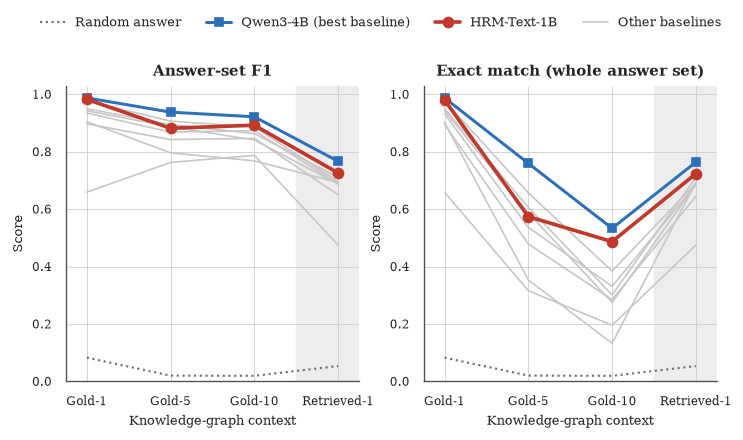

In [10]:
# Full-width `figure*`: MetaQA across the four context variants. Set F1 barely moves while
# exact match collapses, so the two panels use independent y-scales.
def plot_metaqa_context(fname="kgqa_metaqa_context"):
    x = np.arange(len(VARIANT_ORDER))
    fig, axes = plt.subplots(1, 2, figsize=(PAGE_W, 3.2), gridspec_kw={"wspace": 0.22})

    panels = [
        (axes[0], metaqa_f1, "Answer-set F1"),
        (axes[1], metaqa_em, "Exact match (whole answer set)"),
    ]
    for ax, mat, title in panels:
        # Retrieved-1 swaps the gold subgraph for a retriever; it is Gold-1's counterpart.
        ax.axvspan(len(VARIANT_ORDER) - 1.5, len(VARIANT_ORDER) - 0.5,
                   color="0.93", zorder=0)
        for arch in mat.index.drop([HRM_ARCH, METAQA_BEST]):
            ax.plot(x, mat.loc[arch], color="0.78", linewidth=1.0, zorder=1)
        ax.plot(x, metaqa_random, color="0.45", linestyle=":", linewidth=1.3,
                label=RANDOM_LABEL, zorder=2)
        ax.plot(x, mat.loc[METAQA_BEST], color=TRM_COLOR, marker="s", markersize=5,
                linewidth=1.8, label=f"{METAQA_BEST} (best baseline)", zorder=3)
        ax.plot(x, mat.loc[HRM_ARCH], color=ACCENT, marker="o", markersize=6,
                linewidth=2.2, label=HRM_ARCH, zorder=4)

        ax.set_xticks(x)
        ax.set_xticklabels(VARIANT_ORDER, fontsize=8)
        ax.set_xlim(-0.25, len(VARIANT_ORDER) - 0.75)
        ax.set_ylim(0, 1.03)
        ax.set_title(title, fontsize=9)
        ax.set_xlabel("Knowledge-graph context", fontsize=8)
        ax.set_ylabel("Score", fontsize=8)
        ax.tick_params(labelsize=7)
        ax.set_axisbelow(True)

    handles, labels = axes[0].get_legend_handles_labels()
    handles.append(mpl.lines.Line2D([], [], color="0.78", linewidth=1.0))
    labels.append("Other baselines")
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.09),
               ncol=4, fontsize=7.5, frameon=False)
    sns.despine(fig=fig)
    save_fig(fig, fname)
    plt.show()


plot_metaqa_context()


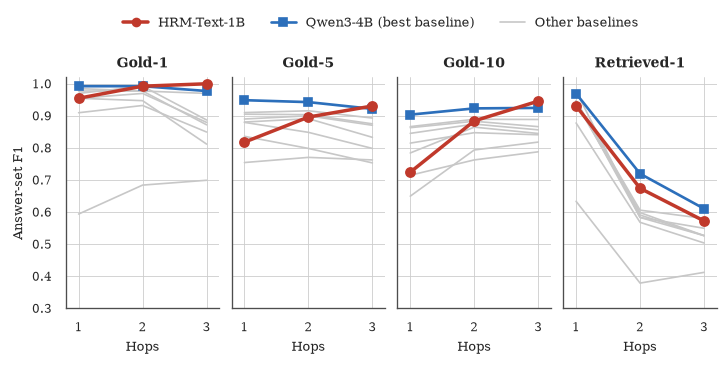

In [11]:
# Full-width `figure*`: answer-set F1 against the number of KG hops the question needs,
# one panel per context variant. This is where HRM-Text and the LLM baselines diverge.
def plot_metaqa_hops(fname="kgqa_metaqa_hops"):
    x = np.arange(len(HOPS))
    fig, axes = plt.subplots(1, len(VARIANT_ORDER), figsize=(PAGE_W, 2.5),
                             sharey=True, gridspec_kw={"wspace": 0.08})

    for ax, variant in zip(axes, VARIANT_ORDER):
        mat = (
            metaqa[metaqa["variant"] == variant]
            .set_index("arch")[[f"val/set_f1_{h}" for h in HOPS]]
            .reindex(METAQA_ORDER)
        )
        for arch in mat.index.drop([HRM_ARCH, METAQA_BEST]):
            ax.plot(x, mat.loc[arch], color="0.78", linewidth=1.0, zorder=1)
        ax.plot(x, mat.loc[METAQA_BEST], color=TRM_COLOR, marker="s", markersize=4.5,
                linewidth=1.6, zorder=3)
        ax.plot(x, mat.loc[HRM_ARCH], color=ACCENT, marker="o", markersize=5.5,
                linewidth=2.1, zorder=4)

        ax.set_xticks(x)
        ax.set_xticklabels([h.replace("hop", "") for h in HOPS], fontsize=8)
        ax.set_xlim(-0.2, len(HOPS) - 0.8)
        ax.set_title(variant, fontsize=8.5)
        ax.set_xlabel("Hops", fontsize=8)
        ax.tick_params(labelsize=7)

    axes[0].set_ylim(0.3, 1.02)
    axes[0].set_ylabel("Answer-set F1", fontsize=8)

    handles = [
        mpl.lines.Line2D([], [], color=ACCENT, marker="o", linewidth=2.1, label=HRM_ARCH),
        mpl.lines.Line2D([], [], color=TRM_COLOR, marker="s", linewidth=1.6,
                         label=f"{METAQA_BEST} (best baseline)"),
        mpl.lines.Line2D([], [], color="0.78", linewidth=1.0, label="Other baselines"),
    ]
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.12),
               ncol=3, fontsize=7.5, frameon=False)
    sns.despine(fig=fig)
    save_fig(fig, fname)
    plt.show()


plot_metaqa_hops()


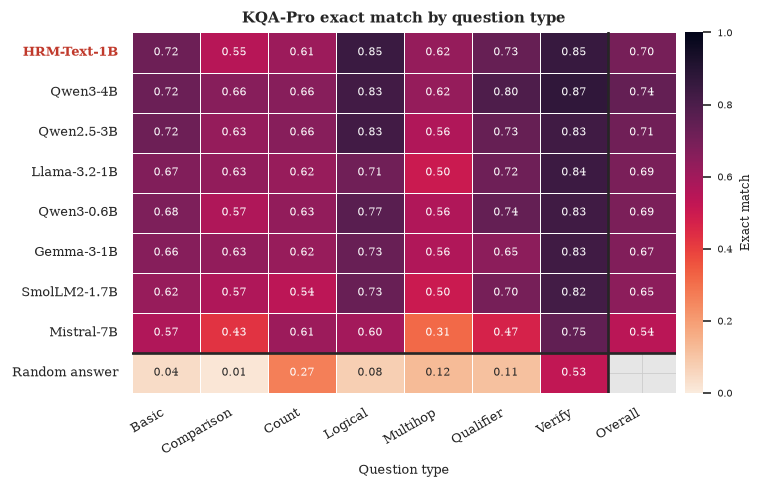

In [12]:
# KQA-Pro by question type. The random-answer row is appended below the separator: Verify
# is binary and Count has a small label set, so a high score there is not evidence of much.
def plot_kqapro_types(fname="kgqa_kqapro_types"):
    grid = kqa_by_type.copy()
    grid["Overall"] = kqapro["val/exact_match"].reindex(KQA_ORDER)
    grid.loc[RANDOM_LABEL] = kqa_random.reindex(grid.columns)  # Overall -> NaN

    fig, ax = plt.subplots(figsize=(PAGE_W, 0.3 * len(grid) + 1.2))
    sns.heatmap(
        grid, mask=grid.isna(), annot=True, fmt=".2f", cmap="rocket_r", vmin=0, vmax=1,
        linewidths=0.4, linecolor="white", annot_kws={"fontsize": 6.5},
        cbar_kws={"label": "Exact match", "pad": 0.015}, ax=ax,
    )
    ax.set_facecolor("0.90")
    ax.axhline(len(KQA_ORDER), color="0.15", linewidth=1.6)
    ax.axvline(len(KQA_TYPES), color="0.15", linewidth=1.6)

    ax.set_xticklabels(grid.columns, rotation=30, ha="right", fontsize=7.5)
    ax.set_yticklabels(grid.index, rotation=0, fontsize=7.5)
    for lbl in ax.get_yticklabels():
        if lbl.get_text() == HRM_ARCH:
            lbl.set_color(ACCENT)
            lbl.set_fontweight("bold")

    ax.set_ylabel("")
    ax.set_xlabel("Question type", fontsize=8)
    ax.set_title("KQA-Pro exact match by question type", fontsize=9)
    ax.figure.axes[-1].yaxis.label.set_size(7)
    ax.figure.axes[-1].tick_params(labelsize=6)
    save_fig(fig, fname)
    plt.show()


plot_kqapro_types()


In [13]:
# Shared LaTeX emitter for the two RQ3 tables: HRM-Text is always the first body row, and
# a trailing random-answer row (if present) is set off by its own rule.
def kgqa_table_latex(tbl, caption, label, column_format, wide=False, rule_before=None):
    lines = tbl.rename_axis(None).to_latex(
        float_format="{:.3f}".format, column_format=column_format,
        escape=False, na_rep="--", multicolumn=True, multicolumn_format="c",
    ).splitlines()
    head = lines.index(r"\midrule")
    lines[head + 1] = lines[head + 1].replace(HRM_ARCH, rf"\textbf{{{HRM_ARCH}}}", 1)
    if rule_before is not None:
        at = next(i for i, ln in enumerate(lines) if ln.startswith(rule_before))
        lines.insert(at, r"\midrule")

    env = "table*" if wide else "table"
    body = [r"\resizebox{\textwidth}{!}{%", *lines, r"}"] if wide else lines
    return "\n".join([
        rf"\begin{{{env}}}[t]", r"\centering", r"\small",
        rf"\caption{{{caption}}}", rf"\label{{{label}}}",
        *body,
        rf"\end{{{env}}}",
    ])


metaqa_table = pd.concat(
    {v: pd.DataFrame({"F1": metaqa_f1[v], "EM": metaqa_em[v]}) for v in VARIANT_ORDER},
    axis=1,
).reindex(columns=pd.MultiIndex.from_product([VARIANT_ORDER, ["F1", "EM"]]))
metaqa_table.loc[RANDOM_LABEL] = [
    metaqa_random[v] for v in VARIANT_ORDER for _ in ("F1", "EM")
]

print(kgqa_table_latex(
    metaqa_table,
    "MetaQA answer-set F1 and exact match (EM) under four knowledge-graph contexts. "
    "\\textbf{Gold-$k$}: gold subgraph, questions with exactly $k$ gold answers. "
    "\\textbf{Retrieved-1}: single-answer questions whose context comes from a retriever "
    "instead of the gold subgraph. The random-answer control is per-variant, hence "
    "identical in both sub-columns.",
    "tab:kgqa_metaqa",
    column_format="l|" + "cc|" * (len(VARIANT_ORDER) - 1) + "cc",
    wide=True,
    rule_before=RANDOM_LABEL,
))

metaqa_table.round(3)


\begin{table*}[t]
\centering
\small
\caption{MetaQA answer-set F1 and exact match (EM) under four knowledge-graph contexts. \textbf{Gold-$k$}: gold subgraph, questions with exactly $k$ gold answers. \textbf{Retrieved-1}: single-answer questions whose context comes from a retriever instead of the gold subgraph. The random-answer control is per-variant, hence identical in both sub-columns.}
\label{tab:kgqa_metaqa}
\resizebox{\textwidth}{!}{%
\begin{tabular}{l|cc|cc|cc|cc}
\toprule
 & \multicolumn{2}{c}{Gold-1} & \multicolumn{2}{c}{Gold-5} & \multicolumn{2}{c}{Gold-10} & \multicolumn{2}{c}{Retrieved-1} \\
 & F1 & EM & F1 & EM & F1 & EM & F1 & EM \\
\midrule
\textbf{HRM-Text-1B} & 0.982 & 0.980 & 0.882 & 0.574 & 0.892 & 0.487 & 0.726 & 0.723 \\
Qwen3-4B & 0.987 & 0.987 & 0.938 & 0.759 & 0.922 & 0.533 & 0.766 & 0.764 \\
Qwen2.5-3B & 0.977 & 0.977 & 0.906 & 0.657 & 0.886 & 0.384 & 0.695 & 0.690 \\
Qwen2.5-1.5B & 0.950 & 0.950 & 0.895 & 0.607 & 0.863 & 0.301 & 0.711 & 0.711 \\
Llama-3.2-1B & 

Gold-1        Gold-5        Gold-10        Retrieved-1       
                  F1     EM     F1     EM      F1     EM          F1     EM
arch                                                                       
HRM-Text-1B    0.982  0.980  0.882  0.574   0.892  0.487       0.726  0.723
Qwen3-4B       0.987  0.987  0.938  0.759   0.922  0.533       0.766  0.764
Qwen2.5-3B     0.977  0.977  0.906  0.657   0.886  0.384       0.695  0.690
Qwen2.5-1.5B   0.950  0.950  0.895  0.607   0.863  0.301       0.711  0.711
Llama-3.2-1B   0.935  0.932  0.868  0.536   0.873  0.331       0.688  0.685
Qwen3-0.6B     0.942  0.942  0.887  0.586   0.841  0.275       0.688  0.685
Gemma-3-1B     0.897  0.895  0.842  0.479   0.847  0.285       0.650  0.645
SmolLM2-1.7B   0.905  0.902  0.796  0.353   0.768  0.132       0.693  0.693
Mistral-7B     0.659  0.659  0.763  0.316   0.787  0.195       0.475  0.475
Random answer  0.083  0.083  0.020  0.020   0.019  0.019       0.053  0.053

In [14]:
kqa_table = kqa_by_type.copy()
kqa_table.insert(0, "Overall", kqapro["val/exact_match"].reindex(KQA_ORDER))
kqa_table.loc[RANDOM_LABEL] = kqa_random.reindex(kqa_table.columns)

print(kgqa_table_latex(
    kqa_table,
    "KQA-Pro exact match, overall and per question type. The random-answer control is "
    "high on Verify (binary) and Count (small label set), so those columns should be read "
    "against it rather than against 0.",
    "tab:kgqa_kqapro",
    column_format="l|c|" + "c" * len(KQA_TYPES),
    wide=True,
    rule_before=RANDOM_LABEL,
))

kqa_table.round(3)


\begin{table*}[t]
\centering
\small
\caption{KQA-Pro exact match, overall and per question type. The random-answer control is high on Verify (binary) and Count (small label set), so those columns should be read against it rather than against 0.}
\label{tab:kgqa_kqapro}
\resizebox{\textwidth}{!}{%
\begin{tabular}{l|c|ccccccc}
\toprule
 & Overall & Basic & Comparison & Count & Logical & Multihop & Qualifier & Verify \\
\midrule
\textbf{HRM-Text-1B} & 0.697 & 0.720 & 0.549 & 0.610 & 0.846 & 0.625 & 0.735 & 0.853 \\
Qwen3-4B & 0.742 & 0.725 & 0.659 & 0.659 & 0.827 & 0.625 & 0.796 & 0.874 \\
Qwen2.5-3B & 0.714 & 0.720 & 0.628 & 0.659 & 0.827 & 0.562 & 0.735 & 0.832 \\
Llama-3.2-1B & 0.688 & 0.672 & 0.634 & 0.622 & 0.712 & 0.500 & 0.716 & 0.842 \\
Qwen3-0.6B & 0.687 & 0.683 & 0.567 & 0.634 & 0.769 & 0.562 & 0.741 & 0.832 \\
Gemma-3-1B & 0.672 & 0.661 & 0.634 & 0.622 & 0.731 & 0.562 & 0.648 & 0.832 \\
SmolLM2-1.7B & 0.647 & 0.624 & 0.567 & 0.537 & 0.731 & 0.500 & 0.698 & 0.821 \\
Mistral-7B &

,Overall,Basic,Comparison,Count,Logical,Multihop,Qualifier,Verify
arch,,,,,,,,
HRM-Text-1B,0.697,0.720,0.549,0.610,0.846,0.625,0.735,0.853
Qwen3-4B,0.742,0.725,0.659,0.659,0.827,0.625,0.796,0.874
Qwen2.5-3B,0.714,0.720,0.628,0.659,0.827,0.562,0.735,0.832
Llama-3.2-1B,0.688,0.672,0.634,0.622,0.712,0.500,0.716,0.842
Qwen3-0.6B,0.687,0.683,0.567,0.634,0.769,0.562,0.741,0.832
Gemma-3-1B,0.672,0.661,0.634,0.622,0.731,0.562,0.648,0.832
SmolLM2-1.7B,0.647,0.624,0.567,0.537,0.731,0.500,0.698,0.821
Mistral-7B,0.539,0.566,0.427,0.610,0.596,0.312,0.469,0.747
Random answer,NaN,0.042,0.012,0.268,0.077,0.125,0.111,0.526
